# Compare scFM Predictions

Load cross-validation results from `training.ipynb` and produce comparison plots across scFMs (scGPT, Geneformer) and cell types (NKT, CD20) for binary and ternary classification.

Figures are saved to `reports/comparison/`.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

RESULTS_DIR = Path("../data/results")
OUTPUT_DIR = Path("../reports/comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCFMS = ["scgpt", "geneformer"]
CELL_TYPES = ["nkt", "cd20"]
TASKS = ["binary", "ternary"]

TASK_LABELS = {
    "binary": ["None", "Relationship"],
    "ternary": ["None", "Activation", "Repression"],
}

SCFM_DISPLAY = {"scgpt": "scGPT", "geneformer": "Geneformer"}
CELL_DISPLAY = {"nkt": "NKT", "cd20": "CD20"}

SCFM_COLORS = {"scgpt": "#1f77b4", "geneformer": "#ff7f0e"}
COMBO_COLORS = {
    ("scgpt", "nkt"): "#1f77b4",
    ("scgpt", "cd20"): "#aec7e8",
    ("geneformer", "nkt"): "#ff7f0e",
    ("geneformer", "cd20"): "#ffbb78",
}

In [2]:
results = {scfm: {ct: {} for ct in CELL_TYPES} for scfm in SCFMS}
for scfm in SCFMS:
    for ct in CELL_TYPES:
        with open(RESULTS_DIR / f"{scfm}_cv_results_{ct}.pkl", "rb") as f:
            payload = pickle.load(f)
        results[scfm][ct]["binary"] = payload["binary"]
        results[scfm][ct]["ternary"] = payload["ternary"]

rows = []
for scfm in SCFMS:
    for ct in CELL_TYPES:
        for task in TASKS:
            cv = results[scfm][ct][task]
            rows.append({
                "scFM": SCFM_DISPLAY[scfm],
                "cell type": CELL_DISPLAY[ct],
                "task": task,
                "n predictions": len(cv.aggregate_predictions),
                "accuracy": cv.aggregate_classification_report["accuracy"],
                "macro F1": cv.aggregate_classification_report["macro avg"]["f1-score"],
            })
pd.DataFrame(rows)

,scFM,cell type,task,n predictions,accuracy,macro F1
0,scGPT,NKT,binary,7895,0.695883,0.695860
1,scGPT,NKT,ternary,3063,0.484492,0.457099
2,scGPT,CD20,binary,8088,0.655910,0.654798
3,scGPT,CD20,ternary,3143,0.432071,0.405982
4,Geneformer,NKT,binary,7882,0.746638,0.746601
5,Geneformer,NKT,ternary,3055,0.534861,0.527830
6,Geneformer,CD20,binary,8076,0.748390,0.748390
7,Geneformer,CD20,ternary,3135,0.540351,0.527726


## 1. Aggregate metrics

Accuracy and macro-F1 by (scFM × cell type) for each task.

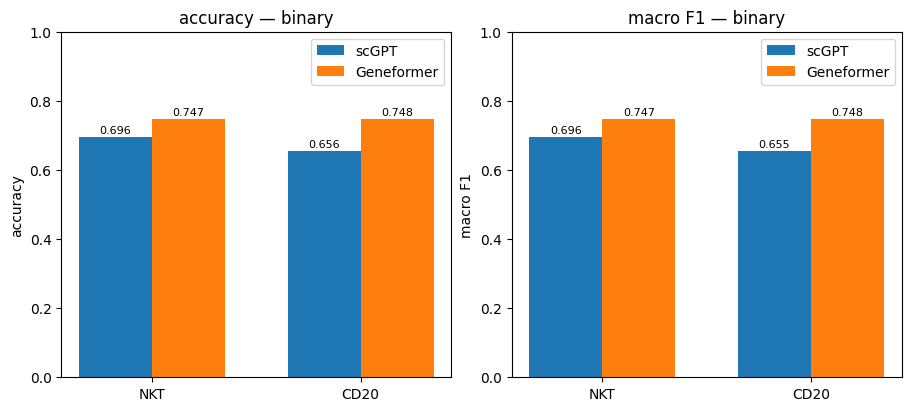

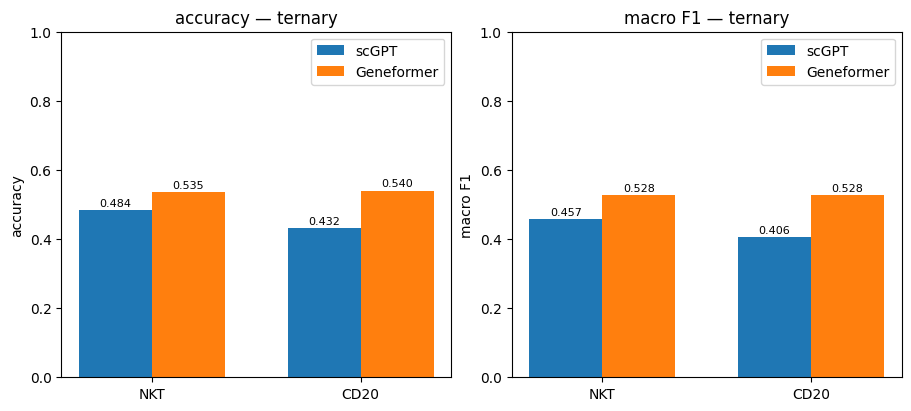

In [3]:
def plot_aggregate_metrics(task):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    x = np.arange(len(CELL_TYPES))
    width = 0.35
    for ax, metric in zip(axes, ["accuracy", "macro F1"]):
        for i, scfm in enumerate(SCFMS):
            values = []
            for ct in CELL_TYPES:
                rpt = results[scfm][ct][task].aggregate_classification_report
                values.append(rpt["accuracy"] if metric == "accuracy" else rpt["macro avg"]["f1-score"])
            offset = (i - 0.5) * width
            bars = ax.bar(x + offset, values, width,
                          label=SCFM_DISPLAY[scfm], color=SCFM_COLORS[scfm])
            for bar, v in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x, [CELL_DISPLAY[ct] for ct in CELL_TYPES])
        ax.set_ylim(0, 1.0)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} — {task}")
        ax.legend()
    out_path = OUTPUT_DIR / f"aggregate_metrics_{task}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

for task in TASKS:
    plot_aggregate_metrics(task)

## 2. Confusion matrices

One 2×2 grid per task (rows = scFM, cols = cell type). Each cell shows row-normalized confusion (so diagonal = per-class recall). Annotations: normalized fraction with raw count in parentheses.

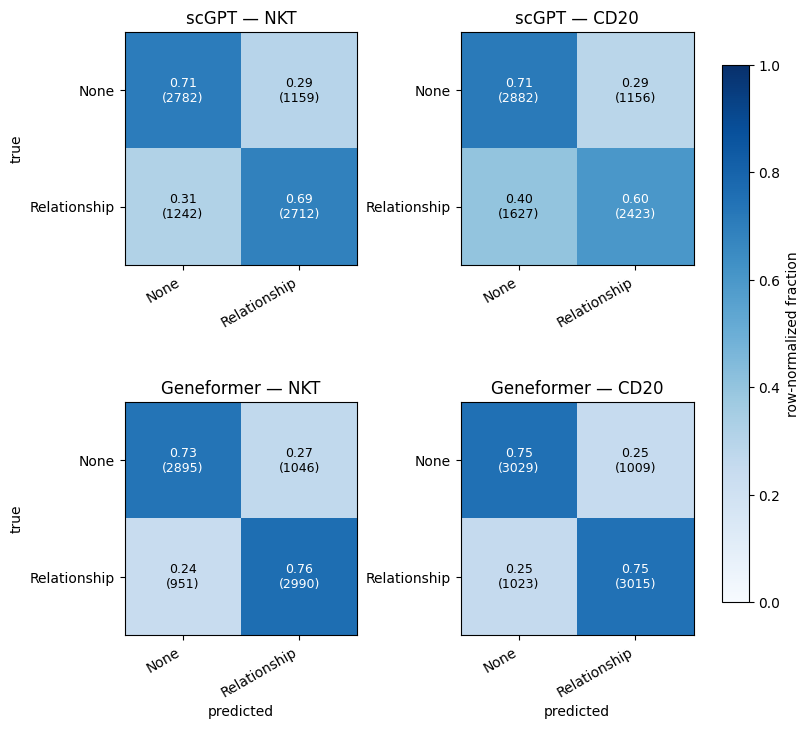

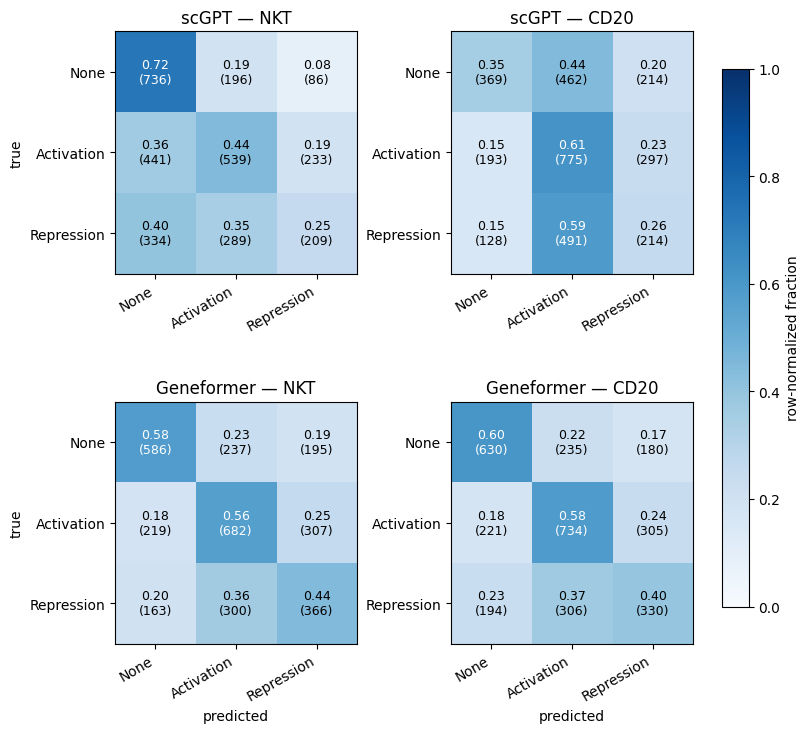

In [4]:
def plot_confusion_matrices(task):
    labels = TASK_LABELS[task]
    fig, axes = plt.subplots(len(SCFMS), len(CELL_TYPES),
                             figsize=(4 * len(CELL_TYPES), 3.8 * len(SCFMS)),
                             constrained_layout=True)
    im = None
    for i, scfm in enumerate(SCFMS):
        for j, ct in enumerate(CELL_TYPES):
            ax = axes[i, j]
            preds = results[scfm][ct][task].aggregate_predictions
            cm = confusion_matrix(preds["true_relationship"],
                                  preds["predicted_relationship"], labels=labels)
            cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
            im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
            for r in range(len(labels)):
                for c in range(len(labels)):
                    color = "white" if cm_norm[r, c] > 0.5 else "black"
                    ax.text(c, r, f"{cm_norm[r, c]:.2f}\n({cm[r, c]})",
                            ha="center", va="center", fontsize=9, color=color)
            ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
            ax.set_yticks(range(len(labels)), labels)
            ax.set_title(f"{SCFM_DISPLAY[scfm]} — {CELL_DISPLAY[ct]}")
            if j == 0:
                ax.set_ylabel("true")
            if i == len(SCFMS) - 1:
                ax.set_xlabel("predicted")
    fig.colorbar(im, ax=axes, shrink=0.75, label="row-normalized fraction")
    out_path = OUTPUT_DIR / f"confusion_matrices_{task}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

for task in TASKS:
    plot_confusion_matrices(task)

## 3. Per-class F1

F1 per class, grouped by (scFM × cell type). Shows whether any class is disproportionately hard.

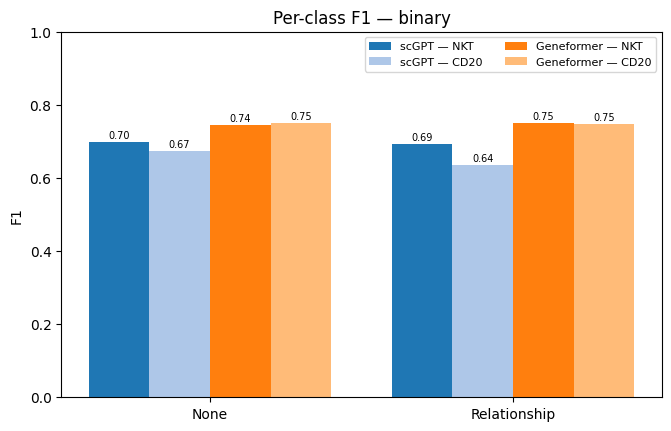

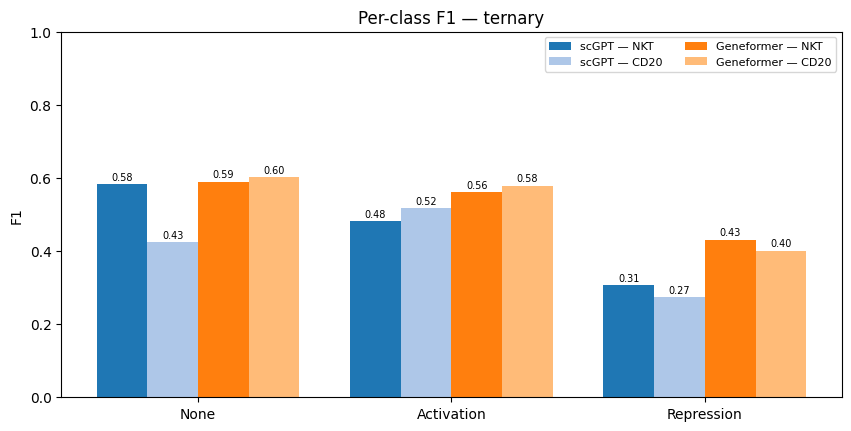

In [5]:
def plot_per_class_f1(task):
    labels = TASK_LABELS[task]
    combos = [(scfm, ct) for scfm in SCFMS for ct in CELL_TYPES]
    x = np.arange(len(labels))
    width = 0.8 / len(combos)
    fig, ax = plt.subplots(figsize=(1.8 * len(labels) + 3, 4.2), constrained_layout=True)
    for k, (scfm, ct) in enumerate(combos):
        rpt = results[scfm][ct][task].aggregate_classification_report
        values = [rpt[lbl]["f1-score"] for lbl in labels]
        offset = (k - (len(combos) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width,
                      label=f"{SCFM_DISPLAY[scfm]} — {CELL_DISPLAY[ct]}",
                      color=COMBO_COLORS[(scfm, ct)])
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x, labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("F1")
    ax.set_title(f"Per-class F1 — {task}")
    ax.legend(fontsize=8, ncol=2)
    out_path = OUTPUT_DIR / f"per_class_f1_{task}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

for task in TASKS:
    plot_per_class_f1(task)

## 4. Cross-scFM agreement

For gene pairs predicted by both scGPT and Geneformer (inner-joined on `(tf, target)`):

**4a. Prediction agreement confusion** — scGPT's predicted label (rows) vs Geneformer's predicted label (cols). Off-diagonal = the models disagree on that pair.

**4b. Correctness breakdown** — for each pair, categorize as both-correct / only-scGPT / only-Geneformer / both-wrong.

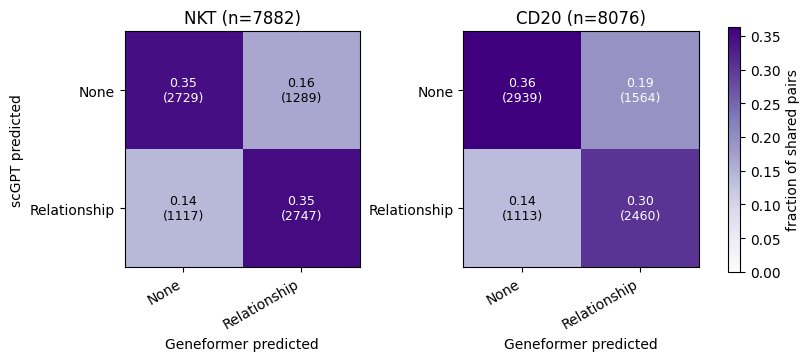

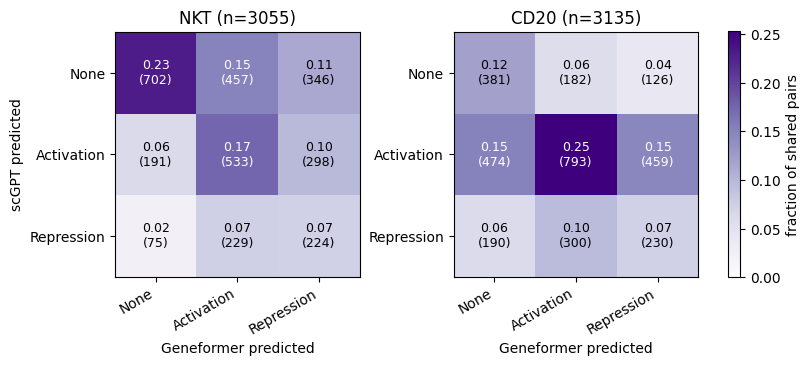

In [6]:
def join_predictions(ct, task):
    scg = results["scgpt"][ct][task].aggregate_predictions
    gnf = results["geneformer"][ct][task].aggregate_predictions
    cols = ["tf", "target", "true_relationship", "predicted_relationship"]
    return scg[cols].merge(
        gnf[cols], on=["tf", "target", "true_relationship"],
        suffixes=("_scgpt", "_geneformer"),
    )

def plot_scfm_agreement_confusion(task):
    labels = TASK_LABELS[task]
    fig, axes = plt.subplots(1, len(CELL_TYPES),
                             figsize=(4 * len(CELL_TYPES), 3.8),
                             constrained_layout=True)
    im = None
    vmax = 0.0
    cms = {}
    for ct in CELL_TYPES:
        joined = join_predictions(ct, task)
        cm = confusion_matrix(joined["predicted_relationship_scgpt"],
                              joined["predicted_relationship_geneformer"],
                              labels=labels)
        cm_norm = cm / max(cm.sum(), 1)
        vmax = max(vmax, float(cm_norm.max()))
        cms[ct] = (cm, cm_norm, len(joined))
    for j, ct in enumerate(CELL_TYPES):
        ax = axes[j]
        cm, cm_norm, n = cms[ct]
        im = ax.imshow(cm_norm, cmap="Purples", vmin=0, vmax=vmax)
        for r in range(len(labels)):
            for c in range(len(labels)):
                color = "white" if cm_norm[r, c] > 0.5 * vmax else "black"
                ax.text(c, r, f"{cm_norm[r, c]:.2f}\n({cm[r, c]})",
                        ha="center", va="center", fontsize=9, color=color)
        ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
        ax.set_yticks(range(len(labels)), labels)
        ax.set_title(f"{CELL_DISPLAY[ct]} (n={n})")
        ax.set_xlabel("Geneformer predicted")
        if j == 0:
            ax.set_ylabel("scGPT predicted")
    fig.colorbar(im, ax=axes, shrink=0.75, label="fraction of shared pairs")
    out_path = OUTPUT_DIR / f"scfm_agreement_confusion_{task}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

for task in TASKS:
    plot_scfm_agreement_confusion(task)

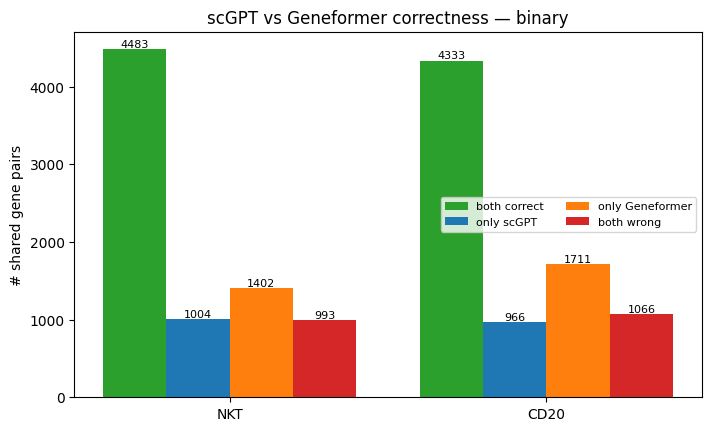

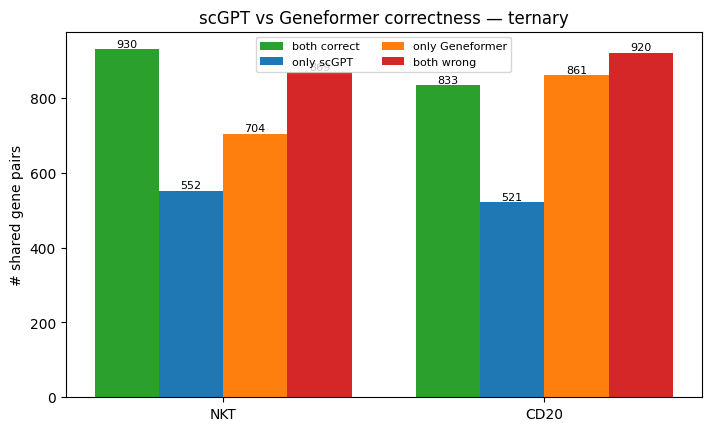

In [7]:
def plot_correctness_breakdown(task):
    categories = ["both correct", "only scGPT", "only Geneformer", "both wrong"]
    cat_colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]
    x = np.arange(len(CELL_TYPES))
    width = 0.8 / len(categories)
    fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
    for k, cat in enumerate(categories):
        values = []
        for ct in CELL_TYPES:
            joined = join_predictions(ct, task)
            scgpt_ok = joined["predicted_relationship_scgpt"] == joined["true_relationship"]
            gnf_ok = joined["predicted_relationship_geneformer"] == joined["true_relationship"]
            if cat == "both correct":
                n = int((scgpt_ok & gnf_ok).sum())
            elif cat == "only scGPT":
                n = int((scgpt_ok & ~gnf_ok).sum())
            elif cat == "only Geneformer":
                n = int((~scgpt_ok & gnf_ok).sum())
            else:
                n = int((~scgpt_ok & ~gnf_ok).sum())
            values.append(n)
        offset = (k - (len(categories) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=cat, color=cat_colors[k])
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, [CELL_DISPLAY[ct] for ct in CELL_TYPES])
    ax.set_ylabel("# shared gene pairs")
    ax.set_title(f"scGPT vs Geneformer correctness — {task}")
    ax.legend(fontsize=8, ncol=2)
    out_path = OUTPUT_DIR / f"scfm_correctness_breakdown_{task}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

for task in TASKS:
    plot_correctness_breakdown(task)